## Project Overview

In this project, my goal is to analyze the population of trees in Minneapolis. We will start by loading the data and creating a DataFrame that has a listing of all trees in the city of Minneapolis as published in the dataset being used. This dataset is not inclusive of every tree in Minneapolis, but does contain a  of the tree population maintained by the city, or tracked by certain nonprofit groups.

We'll get started by loading all of the modules we'll need for the project

In [ ]:
# Load necessary modules
import os
import pandas as pd
import geopandas as gpd
import statsmodels.formula.api as smf

## Load Files
Here we're loading the necessary files. We're going to load a .geojson file which will contain the geo boundaries for Minneapolis neighborhoods as well as a .csv file with contains all of the tree speciments tracked as part of a 2024 academic study of trees in the Twin Cities.

In [ ]:
# Load trees data for Twin Cities Trees
tree_data = pd.read_csv(os.path.join("data", "MSPtrees_2023.csv"))

# Load the GeoJSON file
neighborhoods_geo = gpd.read_file(os.path.join("data", "minneapolis_neighborhoods.geojson"))
print(neighborhoods_geo.crs)

# Load the Neighborhood Housing Data
housing_data = pd.read_csv(os.path.join("data", "neighborhood_housing_data.csv"))

tree_data.head(10)

Let's create an area field in the neighborhoods_geo DataFrame to find the area (in square miles) for each neighborhood

In [ ]:
# Convert neighborhoods_geo to the Minnesota Coordinate Reference System
# This is needed because the earth is a sphere and we need to use mapping specific to Minnesota
# I know all of this and got a lot of help from Gemini here.
neighborhoods_geo = neighborhoods_geo.to_crs(epsg=26915)
neighborhoods_geo['sq_miles'] = neighborhoods_geo.geometry.area / 2589988.11
neighborhoods_geo.loc[neighborhoods_geo["BDNAME"] == "Wenonah"]

# These numbers don't match what I found from the US Census Bureau
# I don't feel like we can trust it
# https://data.census.gov/table?g=050XX00US27053$1400000&d=GEO+Geography+Information

Now we're ready to join the Geo Data to the Trees data

In [ ]:
# Convert the lat & long to Points. Use the same Coordinate Reference System as the GeoJSON
tree_data_geo = gpd.GeoDataFrame(
    tree_data, 
    geometry=gpd.points_from_xy(tree_data.lon, tree_data.lat),
    crs="EPSG:4326" 
)

tree_data_geo = tree_data_geo.to_crs(neighborhoods_geo.crs)

# Join the tree data to the neighborhoods 
tree_data_geo = tree_data_geo.sjoin(neighborhoods_geo, how="left", predicate="intersects", )

## Cleaning Data

This data was pretty clean, but we need to remove some unneeded columns, rename the columns we'll be keeping, and then map some values to create a new column with a more approachable name for each tree specimen.

In [ ]:
# A dictionary will be used to derive a common name for each tree based on the scientific name
# To build this dict, I pulled each tree genus & epithet from the tree_data_geo GeoDataFrame
unique_tree_species = sorted((tree_data_geo["genus"] + " " + tree_data_geo["epithet"]).unique())

# I then fed that list to Gemini and asked it to match each scientific name to the common name and return the info
# as a Python dictionary.
from tree_species import tree_species
list(tree_species.items())[:10]

In [ ]:
# Drop unneeded columns
cols_to_keep = ["entity", "genus", "epithet","city","lat","lon","plot_lvl", "lnd_cvr", "BDNAME"]
tree_data_geo = tree_data_geo[cols_to_keep]

# Rename columns
column_rename_map = {"entity": "collected_by", "givn_nm": "given_name", "plot_lvl": "is_research_plot", "lnd_cvr": "loc_type", "BDNAME":"neighborhood"}
tree_data_geo = tree_data_geo.rename(columns=column_rename_map)

# Add a column for the common name
tree_data_geo["common_name"] = (tree_data_geo["genus"] + " " + tree_data_geo["epithet"]).map(lambda x: tree_species.get(x))
tree_data_geo[["genus","epithet","common_name"]].sample(10)

In [ ]:
# Filter to Minneapolis trees
mpls_trees = tree_data_geo.loc[tree_data_geo["city"]=="Minneapolis"].copy()

# Do we have any trees with a null neighborhood, meaning the geojoin failed?
neighborhoodless_trees = mpls_trees.loc[mpls_trees["neighborhood"].isnull()]
neighborhoodless_trees


Just one lonely Catalpa tree. I looked up the latitude & longitude. It's right on the border of Minneapolis within Theodore Wirth Park, which is part of the Willard - Hay neighborhood here. It's likely mapped just beyond the boundaries indicated in our GeoJSON. Let's fix it manually so we don't lose this one lonely tree.

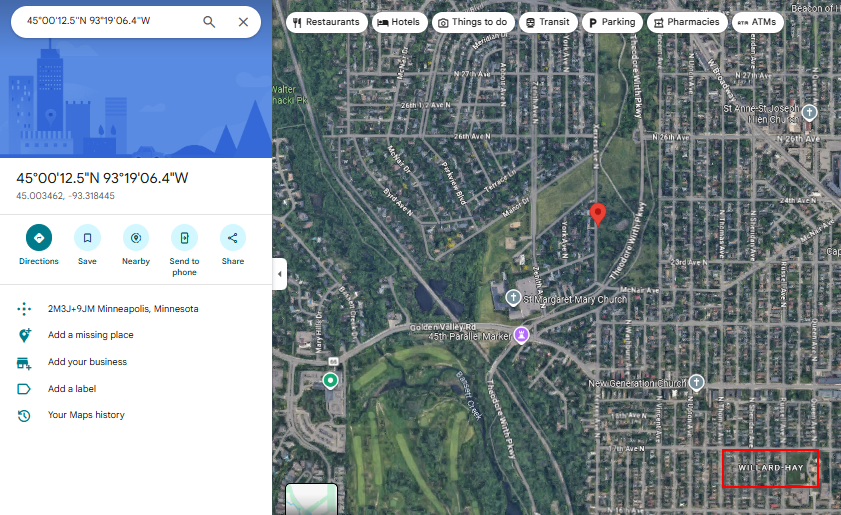

In [ ]:
# Fill all blanks (one tree!) with the Willard-Hay neighborhood
mpls_trees.loc[298066, "neighborhood"] = "Willard - Hay"

mpls_trees.loc[298066]

## Data Exploration

Questions to answer

---

 - What does the population of trees in Minneapolis look like by species?
 - Are certain neighborhoods more likely to have certain types of trees?
 - Do certain neighborhoods have more trees than others?
 - Where are non-profit groups (tracked in this data) most involved?

In [ ]:
# What does the population of trees in Minneapolis look like by species?

# First, find the top 8 trees and rename the other trees
mpls_tree_counts = mpls_trees.value_counts("common_name")[:8]

mpls_trees_top_8 = mpls_trees.copy()
mpls_trees_top_8.loc[~mpls_trees_top_8["common_name"].isin(mpls_tree_counts.index), "common_name"] = "Other"

# Now count the trees belonging to the top 8 trees, and all of the others and create a pie chart
mpls_tree_counts_top_8 = mpls_trees_top_8.value_counts("common_name").sort_values(ascending=True)
mpls_tree_counts_top_8.plot(kind="pie");

In [ ]:
# First, find the top 8 trees and rename the other trees
neighborhood_grouped_trees = mpls_trees.groupby(["neighborhood"])
neighborhood_tree_ratios = neighborhood_grouped_trees["common_name"].value_counts()

# neighborhood_tree_ratios.plot(kind="pie")

### Neighborhood Homeownership Rates
Let's pull in our neighborhood homeownership data now so we can look at if there's a relationship between homeownership rates and tree population

First we need to do some more cleaning

In [ ]:
# Filter Housing Data to only the estimates that we will use for our analysis.
# There is some uncertainty in these estimates, but we're ignoring that for now.

housing_data = housing_data.loc[housing_data["Measure Names"] == "Estimate"]

# Drop all the columns that we don't care about.
housing_data = housing_data[["Neighborhood Name", "Description 1", "Measure Values"]]

# Convert the values to int now that float values are filtered
housing_data["Measure Values"] = housing_data["Measure Values"].astype("Int64")

# Pivot the data to convert from long to wide
housing_data = housing_data.pivot(index="Neighborhood Name", columns = ["Description 1"], values=["Measure Values"])
housing_data

In [ ]:
# Remove MultiIndex from columns
housing_data = housing_data.reset_index(col_level=1)
housing_data.columns = housing_data.columns.droplevel(0)
housing_data.columns.name = None

# Rename columns
column_rename_map = {"Neighborhood Name": "neighborhood", 
                     "owner occupied":"owner_occupied",
                     "renter occupied": "renter_occupied",
                     "occupied housing units": "total_occupied_units",
                     }
housing_data.rename(columns=column_rename_map, inplace=True)

# Reorder Columns
housing_data = housing_data[list(column_rename_map.values())]
housing_data

Eventually we're going to join this DataFrame to aggregated data from `mpls_trees`, but first let's compute the percentages of owner_occupied vs renter_occupied

In [ ]:
# Convert housing_data totals to percentages
housing_data["percent_owner_occupied"] = (housing_data["owner_occupied"] / housing_data["total_occupied_units"]).astype(float).round(4) * 100
housing_data["percent_renter_occupied"] = (housing_data["renter_occupied"] / housing_data["total_occupied_units"]).astype(float).round(4) * 100

### Aggregating Tree Data
Let's calculate some aggregates for tree count by neighborhood

In [ ]:
tree_count_by_neighborhood = pd.DataFrame(mpls_trees.value_counts("neighborhood",)).reset_index().rename(columns={"count": "tree_count"})
tree_count_by_neighborhood

Now we can join our aggregates together.

In [ ]:
tree_count_by_neighborhood = tree_count_by_neighborhood.merge(housing_data, on="neighborhood", how="left")
tree_count_by_neighborhood.sample(10)

In [ ]:
# And plot the output
tree_count_by_neighborhood.plot(kind="scatter", x="percent_owner_occupied", y="tree_count");

Let's now calculate trees per household. Right now, we're not accounting for how many tree there are per person

In [ ]:
tree_count_by_neighborhood["trees_per_household"] = (tree_count_by_neighborhood["tree_count"] / tree_count_by_neighborhood["total_occupied_units"]).astype(float).round(4)
tree_count_by_neighborhood


In [ ]:
# Now plot again
tree_count_by_neighborhood.plot(kind="scatter", x="percent_owner_occupied", y="trees_per_household")

In [ ]:
# Let's find those outliers
tree_count_by_neighborhood.loc[tree_count_by_neighborhood["trees_per_household"] > 4]

I think we can explain these away pretty easily. These neighborhoods (Besides Columbia Park and Kenwood to my knowledge) are highly industrial (I mean two of them have industrial in the name). Because of this, they have very few housing units, but still may have a decent geographic area and therefore number of trees. I think we can surely filter out Camden Industrial (only 54 trees) and Mid-City industrial (only 645 trees) as these are clearly low population, industrial focused neighborhoods where the tree_count per household is inflated due to the low numbers of households in comparison to more residential areas of the city.

Including these in the analysis is not valuable because we want to analyze place where *people live*, and while people surely do live in Camden Industrial & Mid-City Industrial, there are less than 100 housing units between the two neighborhoods, and the neighborhoods have vastly more trees per capita because of it. We're also going to filter Humboldt Industrial Area which has 0 households.

Northeast Park is kind of on the borderline. I know there is some industrial activity there, but having 315 households is sizable housing. I'm less included to rule it out as an outlier. We'll just call is an unusual data point, but keep it in the dataset for this analysis.

In [ ]:
# Filter the outliers
tree_count_by_neighborhood = tree_count_by_neighborhood.loc[~tree_count_by_neighborhood["neighborhood"].isin(["Mid - City Industrial", "Camden Industrial", "Humboldt Industrial Area"])]
tree_count_by_neighborhood.sort_values("tree_count", ascending=False)

In [ ]:
# And plot one more time
tree_count_by_neighborhood.plot(kind="scatter", x="percent_owner_occupied", y="trees_per_household");

## Regression
Le'ts now make a regrassion model of our predictor (owner_occupied_%) and responding variable (trees_per_houshold)

In [ ]:
model = smf.ols(formula="trees_per_household ~ percent_owner_occupied", data=tree_count_by_neighborhood).fit()
model.summary()